In [ ]:
# Brain MRI classification with three PyTorch deep-learning models
# Classes: glioma, meningioma, notumor, pituitary
# Required notebook kernel: c:\SDE Projects\DL\.venv\Scripts\python.exe (DL Project (PyTorch cu130))

from pathlib import Path
import copy
import random
import time
import os
import gc

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
REQUIRE_CUDA = True
CUDA_DEVICE_INDEX = 0

print(f"Python executable: {os.sys.executable}")
print(f"PyTorch version: {torch.__version__}")
print(f"PyTorch CUDA build: {torch.version.cuda}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA device count: {torch.cuda.device_count()}")

if REQUIRE_CUDA and not torch.cuda.is_available():
    raise RuntimeError("CUDA is not visible. Select the DL Project (PyTorch cu130) kernel and restart the kernel.")
if CUDA_DEVICE_INDEX >= torch.cuda.device_count():
    raise RuntimeError(f"Requested CUDA device {CUDA_DEVICE_INDEX}, but only {torch.cuda.device_count()} device(s) are visible.")

device = torch.device(f"cuda:{CUDA_DEVICE_INDEX}")
torch.cuda.set_device(device)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(device)}")
print(f"GPU memory: {torch.cuda.get_device_properties(device).total_memory / 1024**3:.2f} GB")
gpu_test = torch.randn((512, 512), device=device)
print(f"GPU tensor test passed: {(gpu_test @ gpu_test).mean().item():.6f}")
del gpu_test
torch.cuda.empty_cache()

PROJECT_DIR = Path.cwd()
TRAIN_DIR = PROJECT_DIR / "Training"
TEST_DIR = PROJECT_DIR / "Testing"
IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 0

if not TRAIN_DIR.exists() or not TEST_DIR.exists():
    raise FileNotFoundError(f"Expected Training and Testing folders beside the notebook. Current folder: {PROJECT_DIR}")

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transforms)
if train_dataset.classes != test_dataset.classes:
    raise ValueError(f"Train/test class mismatch: {train_dataset.classes} vs {test_dataset.classes}")
class_names = train_dataset.classes
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
print(f"Classes: {class_names}")
print(f"Training images: {len(train_dataset):,}")
print(f"Testing images: {len(test_dataset):,}")
images, labels = next(iter(train_loader))
print(f"Batch size: {BATCH_SIZE} | First batch shape: {tuple(images.shape)} | labels: {tuple(labels.shape)}")

Python executable: c:\SDE Projects\DL\.venv\Scripts\python.exe
PyTorch version: 2.13.0+cu130
PyTorch CUDA build: 13.0
CUDA available: True
CUDA device count: 1
Using device: cuda:0
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
GPU memory: 7.96 GB
GPU tensor test passed: -0.011960
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Training images: 5,600
Testing images: 1,600
Batch size: 16 | First batch shape: (16, 3, 224, 224) | labels: (16,)


Preprocessing pipeline:
  Train: resize -> horizontal flip -> rotation -> brightness/contrast jitter -> normalize
  Test: resize -> normalize
  Image size: 224x224
  Normalization mean: [0.485, 0.456, 0.406]
  Normalization std: [0.229, 0.224, 0.225]

Class distribution:
  glioma: train=1400, test=400
  meningioma: train=1400, test=400
  notumor: train=1400, test=400
  pituitary: train=1400, test=400


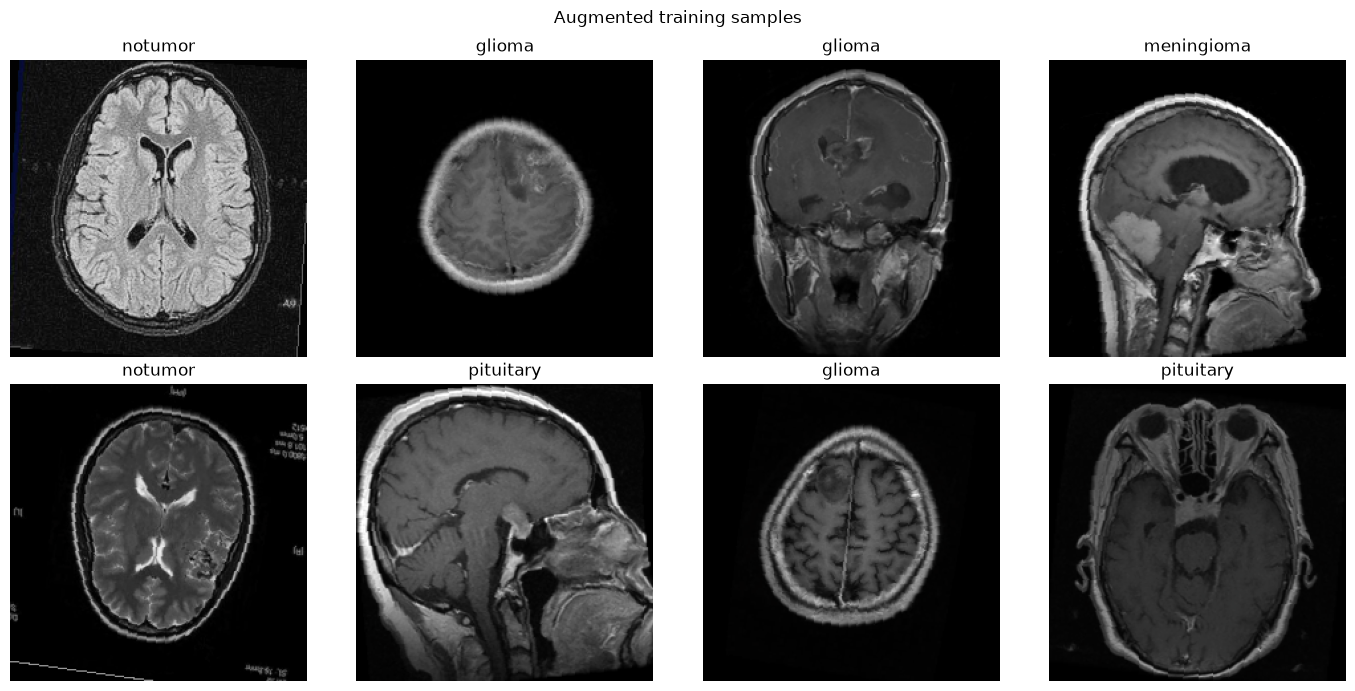

In [ ]:
# Data preprocessing and augmentation inspection
from collections import Counter

print("Preprocessing pipeline:")
print("  Train: resize -> horizontal flip -> rotation -> brightness/contrast jitter -> normalize")
print("  Test: resize -> normalize")
print(f"  Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  Normalization mean: {[0.485, 0.456, 0.406]}")
print(f"  Normalization std: {[0.229, 0.224, 0.225]}")

train_counts = Counter(train_dataset.targets)
test_counts = Counter(test_dataset.targets)
print("\nClass distribution:")
for index, class_name in enumerate(class_names):
    print(f"  {class_name}: train={train_counts[index]}, test={test_counts[index]}")

sample_images, sample_labels = next(iter(train_loader))
figure, axes = plt.subplots(2, 4, figsize=(14, 7))
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
for axis, image_tensor, label in zip(axes.flat, sample_images[:8], sample_labels[:8]):
    image = (image_tensor * std + mean).clamp(0, 1).permute(1, 2, 0)
    axis.imshow(image)
    axis.set_title(class_names[label.item()])
    axis.axis("off")
figure.suptitle("Augmented training samples")
figure.tight_layout()
plt.show()

In [ ]:
import gc

class BrainCNN(nn.Module):
    """A compact CNN trained from scratch."""
    def __init__(self, number_of_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.4), nn.Linear(256, number_of_classes)
        )

    def forward(self, inputs):
        return self.classifier(self.features(inputs))


def create_resnet(number_of_classes):
    try:
        weights = models.ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)
    except Exception as error:
        print(f"Could not download ResNet weights ({error}); using random initialization.")
        model = models.resnet18(weights=None)
    for parameter in model.parameters():
        parameter.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, number_of_classes)
    return model


def create_mobilenet(number_of_classes):
    try:
        weights = models.MobileNet_V3_Small_Weights.DEFAULT
        model = models.mobilenet_v3_small(weights=weights)
    except Exception as error:
        print(f"Could not download MobileNet weights ({error}); using random initialization.")
        model = models.mobilenet_v3_small(weights=None)
    for parameter in model.parameters():
        parameter.requires_grad = False
    model.classifier[3] = nn.Linear(model.classifier[3].in_features, number_of_classes)
    return model

models_to_train = {
    "Custom CNN": BrainCNN(len(class_names)),
    "ResNet18": create_resnet(len(class_names)),
    "MobileNetV3": create_mobilenet(len(class_names)),
}

# Keep all models on CPU until their dedicated training block runs.
# Only one model is placed on the 8 GB GPU at a time.
for model in models_to_train.values():
    model.to("cpu")

gc.collect()
torch.cuda.empty_cache()
print("Models ready. Only the active model will be moved to CUDA during training:")
for name, model in models_to_train.items():
    trainable = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
    print(f"  {name}: {trainable:,} trainable parameters")

Models ready. Only the active model will be moved to CUDA during training:
  Custom CNN: 390,404 trainable parameters
  ResNet18: 2,052 trainable parameters
  MobileNetV3: 4,100 trainable parameters


In [ ]:
EPOCHS = 50
LEARNING_RATE = 1e-3
LABEL_SMOOTHING = 0.1
GRADIENT_CLIP_VALUE = 1.0
OUTPUT_DIR = PROJECT_DIR / "saved_models"
OUTPUT_DIR.mkdir(exist_ok=True)

from datetime import datetime
import json
import uuid
from IPython.display import display

RUN_ID = f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_{uuid.uuid4().hex[:8]}"
RUN_DIR = OUTPUT_DIR / f"run_{RUN_ID}"
RUN_DIR.mkdir(exist_ok=True)
print(f"Unique run folder: {RUN_DIR}")


def metrics_from_predictions(labels, predictions, number_of_classes, confidences=None):
    matrix = np.zeros((number_of_classes, number_of_classes), dtype=np.int64)
    for actual, predicted in zip(labels, predictions):
        matrix[actual, predicted] += 1

    true_positives = np.diag(matrix).astype(np.float64)
    predicted_totals = matrix.sum(axis=0)
    actual_totals = matrix.sum(axis=1)
    precision = np.divide(true_positives, predicted_totals, out=np.zeros(number_of_classes), where=predicted_totals != 0)
    recall = np.divide(true_positives, actual_totals, out=np.zeros(number_of_classes), where=actual_totals != 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros(number_of_classes), where=(precision + recall) != 0)
    return {
        "accuracy": float(np.trace(matrix) / matrix.sum()),
        "precision": float(precision.mean()),
        "recall": float(recall.mean()),
        "f1": float(f1.mean()),
        "mean_confidence": float(np.mean(confidences)) if confidences else 0.0,
        "uncertainty": float(1.0 - np.mean(confidences)) if confidences else 1.0,
        "matrix": matrix,
    }


def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total = 0
    all_labels = []
    all_predictions = []
    all_confidences = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, predictions = probabilities.max(1)
            total_loss += criterion(outputs, labels).item() * inputs.size(0)
            all_labels.extend(labels.cpu().tolist())
            all_predictions.extend(predictions.cpu().tolist())
            all_confidences.extend(confidence.cpu().tolist())
            total += labels.size(0)
    metrics = metrics_from_predictions(all_labels, all_predictions, len(class_names), all_confidences)
    metrics["loss"] = float(total_loss / total)
    return metrics


def show_live_dashboard(model_name, history, train_metrics, test_metrics, epoch):
    figure, axes = plt.subplots(2, 2, figsize=(14, 10))
    epochs_seen = range(1, epoch + 2)
    axes[0, 0].plot(epochs_seen, history["train_loss"], marker="o", label="Train")
    axes[0, 0].plot(epochs_seen, history["test_loss"], marker="o", label="Test")
    axes[0, 0].set_title(f"{model_name}: loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Cross-entropy loss")
    axes[0, 1].plot(epochs_seen, history["train_accuracy"], marker="o", label="Train")
    axes[0, 1].plot(epochs_seen, history["test_accuracy"], marker="o", label="Test")
    axes[0, 1].set_title(f"{model_name}: accuracy")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Accuracy")
    for split, color in (("train", "tab:blue"), ("test", "tab:orange")):
        axes[1, 0].plot(epochs_seen, history[f"{split}_precision"], color=color, label=f"{split} precision")
        axes[1, 0].plot(epochs_seen, history[f"{split}_recall"], color=color, linestyle="--", label=f"{split} recall")
        axes[1, 0].plot(epochs_seen, history[f"{split}_f1"], color=color, linestyle=":", label=f"{split} F1")
    axes[1, 0].set_title("Macro precision, recall, F1")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Score")
    axes[1, 0].set_ylim(0, 1.05)
    axes[1, 1].axis("off")
    axes[1, 1].text(0.02, 0.95, "Train confusion matrix", weight="bold", transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.02, 0.89, str(train_metrics["matrix"]), family="monospace", transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.52, 0.95, "Test confusion matrix", weight="bold", transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.52, 0.89, str(test_metrics["matrix"]), family="monospace", transform=axes[1, 1].transAxes)
    axes[1, 1].text(0.02, 0.08, f"Rows=true, columns=predicted\nClass order: {class_names}\nTest confidence: {test_metrics['mean_confidence']:.3f}\nTest uncertainty: {test_metrics['uncertainty']:.3f}", transform=axes[1, 1].transAxes)
    for axis in axes.flat[:3]:
        axis.grid(alpha=0.25)
        axis.legend(fontsize=8)
    figure.tight_layout()
    dashboard_path = RUN_DIR / f"{model_name.lower().replace(' ', '_')}_epoch_{epoch + 1:03d}.png"
    figure.savefig(dashboard_path, dpi=150, bbox_inches="tight")
    display(figure)
    plt.close(figure)
    return dashboard_path


def save_metrics_json(model_name, history, latest_train, latest_test, epoch):
    payload = {
        "run_id": RUN_ID,
        "model_name": model_name,
        "class_names": class_names,
        "epoch_completed": epoch,
        "optimizer": "Adam + ReduceLROnPlateau",
        "label_smoothing": LABEL_SMOOTHING,
        "gradient_clip_value": GRADIENT_CLIP_VALUE,
        "history": history,
        "latest_train_metrics": {key: value.tolist() if isinstance(value, np.ndarray) else value for key, value in latest_train.items()},
        "latest_test_metrics": {key: value.tolist() if isinstance(value, np.ndarray) else value for key, value in latest_test.items()},
    }
    metrics_path = RUN_DIR / f"{model_name.lower().replace(' ', '_')}_{RUN_ID}_metrics.json"
    with metrics_path.open("w", encoding="utf-8") as file:
        json.dump(payload, file, indent=2)
    return metrics_path


def train_one_model(model, model_name, epochs=EPOCHS):
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    optimizer = torch.optim.Adam((parameter for parameter in model.parameters() if parameter.requires_grad), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6)
    metric_names = ["loss", "accuracy", "precision", "recall", "f1", "mean_confidence", "uncertainty"]
    history = {f"{split}_{metric}": [] for split in ("train", "test") for metric in metric_names}
    history["learning_rate"] = []
    history["train_confusion_matrices"] = []
    history["test_confusion_matrices"] = []
    best_accuracy = -1.0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        running_loss = 0.0
        total = 0
        train_labels = []
        train_predictions = []
        train_confidences = []
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_VALUE)
            optimizer.step()
            probabilities = torch.softmax(outputs.detach(), dim=1)
            confidence, predictions = probabilities.max(1)
            running_loss += loss.item() * inputs.size(0)
            train_labels.extend(labels.cpu().tolist())
            train_predictions.extend(predictions.cpu().tolist())
            train_confidences.extend(confidence.cpu().tolist())
            total += labels.size(0)

        train_metrics = metrics_from_predictions(train_labels, train_predictions, len(class_names), train_confidences)
        train_metrics["loss"] = float(running_loss / total)
        test_metrics = evaluate_model(model, test_loader, criterion)
        scheduler.step(test_metrics["loss"])
        current_lr = float(optimizer.param_groups[0]["lr"])
        for split, metrics in (("train", train_metrics), ("test", test_metrics)):
            for metric in metric_names:
                history[f"{split}_{metric}"].append(float(metrics[metric]))
        history["learning_rate"].append(current_lr)
        history["train_confusion_matrices"].append(train_metrics["matrix"].tolist())
        history["test_confusion_matrices"].append(test_metrics["matrix"].tolist())

        metrics_path = save_metrics_json(model_name, history, train_metrics, test_metrics, epoch + 1)
        dashboard_path = show_live_dashboard(model_name, history, train_metrics, test_metrics, epoch)
        print(f"{model_name} | Epoch {epoch + 1}/{epochs} | TRAIN loss={train_metrics['loss']:.4f} acc={train_metrics['accuracy']:.4f} precision={train_metrics['precision']:.4f} recall={train_metrics['recall']:.4f} f1={train_metrics['f1']:.4f} confidence={train_metrics['mean_confidence']:.4f}")
        print(f"{model_name} | Epoch {epoch + 1}/{epochs} | TEST  loss={test_metrics['loss']:.4f} acc={test_metrics['accuracy']:.4f} precision={test_metrics['precision']:.4f} recall={test_metrics['recall']:.4f} f1={test_metrics['f1']:.4f} confidence={test_metrics['mean_confidence']:.4f} uncertainty={test_metrics['uncertainty']:.4f}")
        print(f"TRAIN confusion matrix:\n{train_metrics['matrix']}\nTEST confusion matrix:\n{test_metrics['matrix']}")
        print(f"Learning rate: {current_lr:.8f} | JSON: {metrics_path} | Graph: {dashboard_path}")
        print(f"Epoch time: {time.time() - start_time:.1f}s\n")
        if test_metrics["accuracy"] > best_accuracy:
            best_accuracy = test_metrics["accuracy"]
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    model_file = RUN_DIR / f"{model_name.lower().replace(' ', '_')}_{RUN_ID}_best.pth"
    torch.save({"model_state_dict": model.state_dict(), "class_names": class_names, "image_size": IMAGE_SIZE, "model_name": model_name, "run_id": RUN_ID}, model_file)
    print(f"Unique {model_name} model saved to: {model_file}")
    return history


histories = {}
print("Shared training functions are ready. Run the three model cells below.")

Unique run folder: c:\SDE Projects\DL\saved_models\run_20260830_145713_c0f38415
Shared training functions are ready. Run the three model cells below.


In [ ]:
# GPU-safe trainer override: one model on CUDA at a time with mixed precision.
# Run this cell after the shared training-functions cell and before the three algorithm cells.

def train_one_model(model, model_name, epochs=EPOCHS):
    for other_name, other_model in models_to_train.items():
        if other_name != model_name:
            other_model.to("cpu")
    model.to(device)
    gc.collect()
    torch.cuda.empty_cache()

    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    optimizer = torch.optim.Adam(
        (parameter for parameter in model.parameters() if parameter.requires_grad),
        lr=LEARNING_RATE,
        weight_decay=1e-4,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6
    )
    scaler = torch.amp.GradScaler("cuda", enabled=True)
    metric_names = ["loss", "accuracy", "precision", "recall", "f1", "mean_confidence", "uncertainty"]
    history = {f"{split}_{metric}": [] for split in ("train", "test") for metric in metric_names}
    history["learning_rate"] = []
    history["train_confusion_matrices"] = []
    history["test_confusion_matrices"] = []
    best_accuracy = -1.0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        running_loss = 0.0
        total = 0
        train_labels, train_predictions, train_confidences = [], [], []

        for inputs, labels in train_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=True):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_VALUE)
            scaler.step(optimizer)
            scaler.update()
            probabilities = torch.softmax(outputs.detach().float(), dim=1)
            confidence, predictions = probabilities.max(1)
            running_loss += loss.item() * inputs.size(0)
            train_labels.extend(labels.cpu().tolist())
            train_predictions.extend(predictions.cpu().tolist())
            train_confidences.extend(confidence.cpu().tolist())
            total += labels.size(0)

        train_metrics = metrics_from_predictions(train_labels, train_predictions, len(class_names), train_confidences)
        train_metrics["loss"] = float(running_loss / total)
        test_metrics = evaluate_model(model, test_loader, criterion)
        scheduler.step(test_metrics["loss"])
        current_lr = float(optimizer.param_groups[0]["lr"])

        for split, metrics in (("train", train_metrics), ("test", test_metrics)):
            for metric in metric_names:
                history[f"{split}_{metric}"].append(float(metrics[metric]))
        history["learning_rate"].append(current_lr)
        history["train_confusion_matrices"].append(train_metrics["matrix"].tolist())
        history["test_confusion_matrices"].append(test_metrics["matrix"].tolist())

        metrics_path = save_metrics_json(model_name, history, train_metrics, test_metrics, epoch + 1)
        dashboard_path = show_live_dashboard(model_name, history, train_metrics, test_metrics, epoch)
        print(f"{model_name} | Epoch {epoch + 1}/{epochs} | TRAIN loss={train_metrics['loss']:.4f} acc={train_metrics['accuracy']:.4f} precision={train_metrics['precision']:.4f} recall={train_metrics['recall']:.4f} f1={train_metrics['f1']:.4f}")
        print(f"{model_name} | Epoch {epoch + 1}/{epochs} | TEST loss={test_metrics['loss']:.4f} acc={test_metrics['accuracy']:.4f} precision={test_metrics['precision']:.4f} recall={test_metrics['recall']:.4f} f1={test_metrics['f1']:.4f}")
        print(f"TEST confidence={test_metrics['mean_confidence']:.4f} uncertainty={test_metrics['uncertainty']:.4f} learning_rate={current_lr:.8f}")
        print(f"TRAIN confusion matrix:\n{train_metrics['matrix']}\nTEST confusion matrix:\n{test_metrics['matrix']}")
        print(f"JSON: {metrics_path} | Graph: {dashboard_path} | Epoch time: {time.time() - start_time:.1f}s\n")

        if test_metrics["accuracy"] > best_accuracy:
            best_accuracy = test_metrics["accuracy"]
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    model_file = RUN_DIR / f"{model_name.lower().replace(' ', '_')}_{RUN_ID}_best.pth"
    torch.save({"model_state_dict": model.state_dict(), "class_names": class_names, "image_size": IMAGE_SIZE, "model_name": model_name, "run_id": RUN_ID}, model_file)
    print(f"Unique {model_name} model saved to: {model_file}")
    torch.cuda.empty_cache()
    return history

print("GPU-safe mixed-precision trainer is ready.")

GPU-safe mixed-precision trainer is ready.


Starting Custom CNN training for 50 epochs...


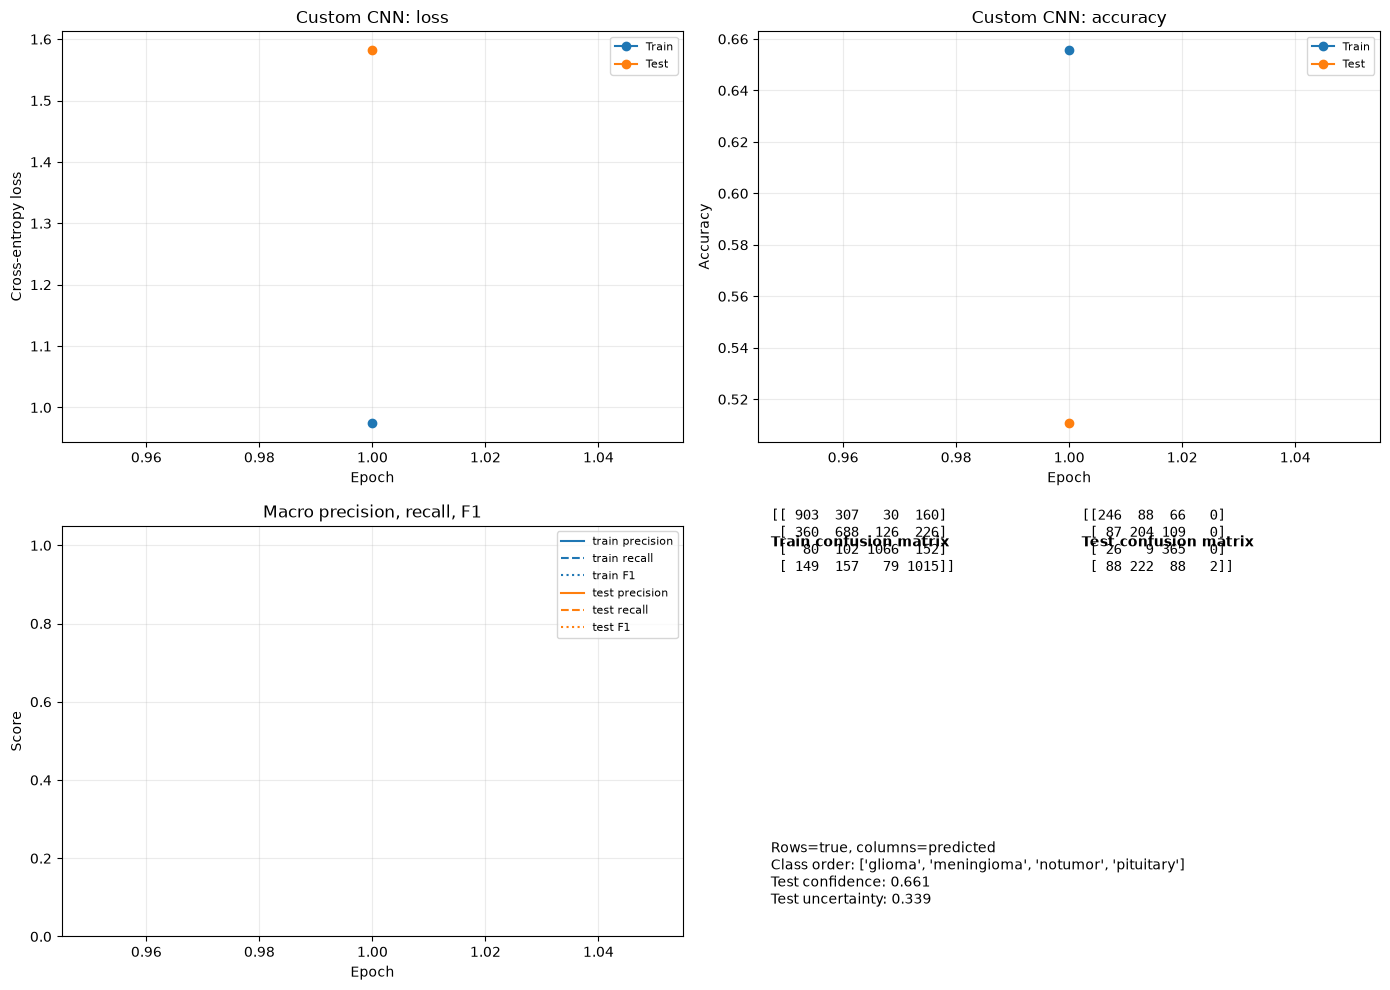

Custom CNN | Epoch 1/50 | TRAIN loss=0.9741 acc=0.6557 precision=0.6567 recall=0.6557 f1=0.6549
Custom CNN | Epoch 1/50 | TEST loss=1.5823 acc=0.5106 precision=0.6304 recall=0.5106 f1=0.4357
TEST confidence=0.6614 uncertainty=0.3386 learning_rate=0.00100000
TRAIN confusion matrix:
[[ 903  307   30  160]
 [ 360  688  126  226]
 [  80  102 1066  152]
 [ 149  157   79 1015]]
TEST confusion matrix:
[[246  88  66   0]
 [ 87 204 109   0]
 [ 26   9 365   0]
 [ 88 222  88   2]]
JSON: c:\SDE Projects\DL\saved_models\run_20260830_145713_c0f38415\custom_cnn_20260830_145713_c0f38415_metrics.json | Graph: c:\SDE Projects\DL\saved_models\run_20260830_145713_c0f38415\custom_cnn_epoch_001.png | Epoch time: 55.3s



RuntimeError: [enforce fail at alloc_cpu.cpp:117] data. DefaultCPUAllocator: not enough memory: you tried to allocate 9633792 bytes.

In [ ]:
# Algorithm 1: Custom CNN - 50 epochs
print("Starting Custom CNN training for 50 epochs...")
histories["Custom CNN"] = train_one_model(models_to_train["Custom CNN"], "Custom CNN", epochs=50)
print("Custom CNN 50-epoch training finished.")

In [ ]:
# Algorithm 2: ResNet18 transfer learning - 50 epochs
print("Starting ResNet18 training for 50 epochs...")
histories["ResNet18"] = train_one_model(models_to_train["ResNet18"], "ResNet18", epochs=50)
print("ResNet18 50-epoch training finished.")

In [ ]:
# Algorithm 3: MobileNetV3 transfer learning - 50 epochs
print("Starting MobileNetV3 training for 50 epochs...")
histories["MobileNetV3"] = train_one_model(models_to_train["MobileNetV3"], "MobileNetV3", epochs=50)
all_metrics_path = RUN_DIR / f"all_models_{RUN_ID}_metrics.json"
with all_metrics_path.open("w", encoding="utf-8") as file:
    json.dump({"run_id": RUN_ID, "class_names": class_names, "epochs": 50, "models": histories}, file, indent=2)
print("MobileNetV3 50-epoch training finished.")
print(f"All model metrics saved to: {all_metrics_path}")


Custom CNN final test metrics:
loss=0.8900 | accuracy=0.7612 | precision=0.7688 | recall=0.7613 | f1=0.7501
Class            Precision      Recall    F1-score     Support
glioma               0.864       0.620       0.722         400
meningioma           0.697       0.522       0.597         400
notumor              0.703       0.990       0.822         400
pituitary            0.811       0.912       0.859         400

Overall accuracy: 0.761


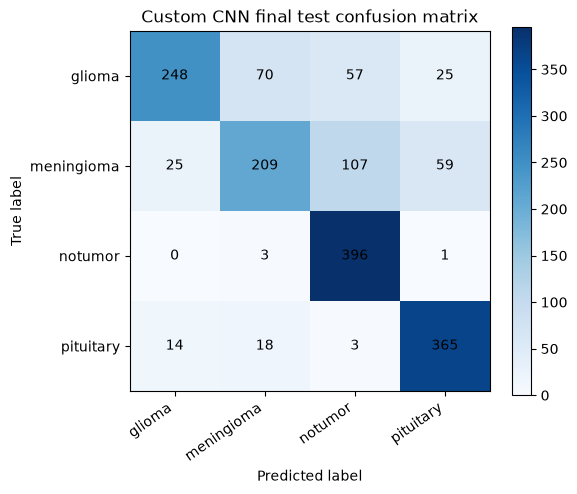


ResNet18 final test metrics:
loss=0.5540 | accuracy=0.8187 | precision=0.8395 | recall=0.8187 | f1=0.8140
Class            Precision      Recall    F1-score     Support
glioma               0.954       0.573       0.716         400
meningioma           0.666       0.802       0.728         400
notumor              0.827       0.980       0.897         400
pituitary            0.911       0.920       0.915         400

Overall accuracy: 0.819


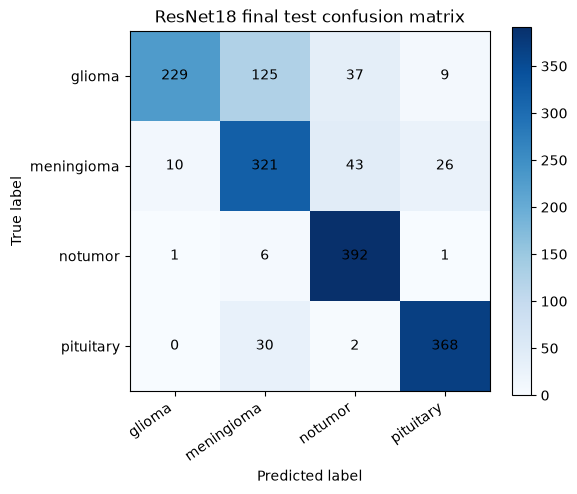


MobileNetV3 final test metrics:
loss=0.5702 | accuracy=0.8187 | precision=0.8289 | recall=0.8187 | f1=0.8148
Class            Precision      Recall    F1-score     Support
glioma               0.899       0.647       0.753         400
meningioma           0.745       0.723       0.734         400
notumor              0.751       0.983       0.852         400
pituitary            0.920       0.922       0.921         400

Overall accuracy: 0.819


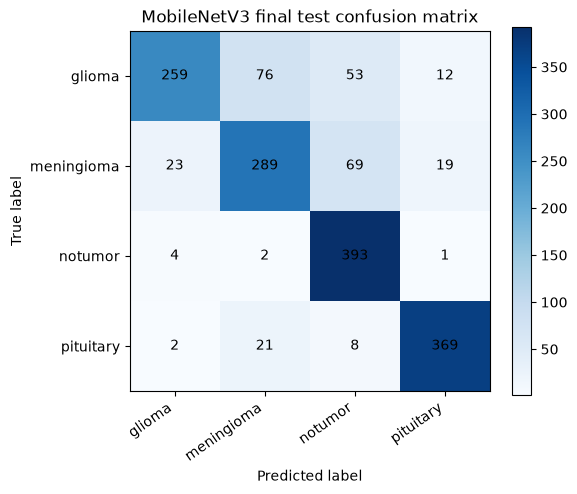

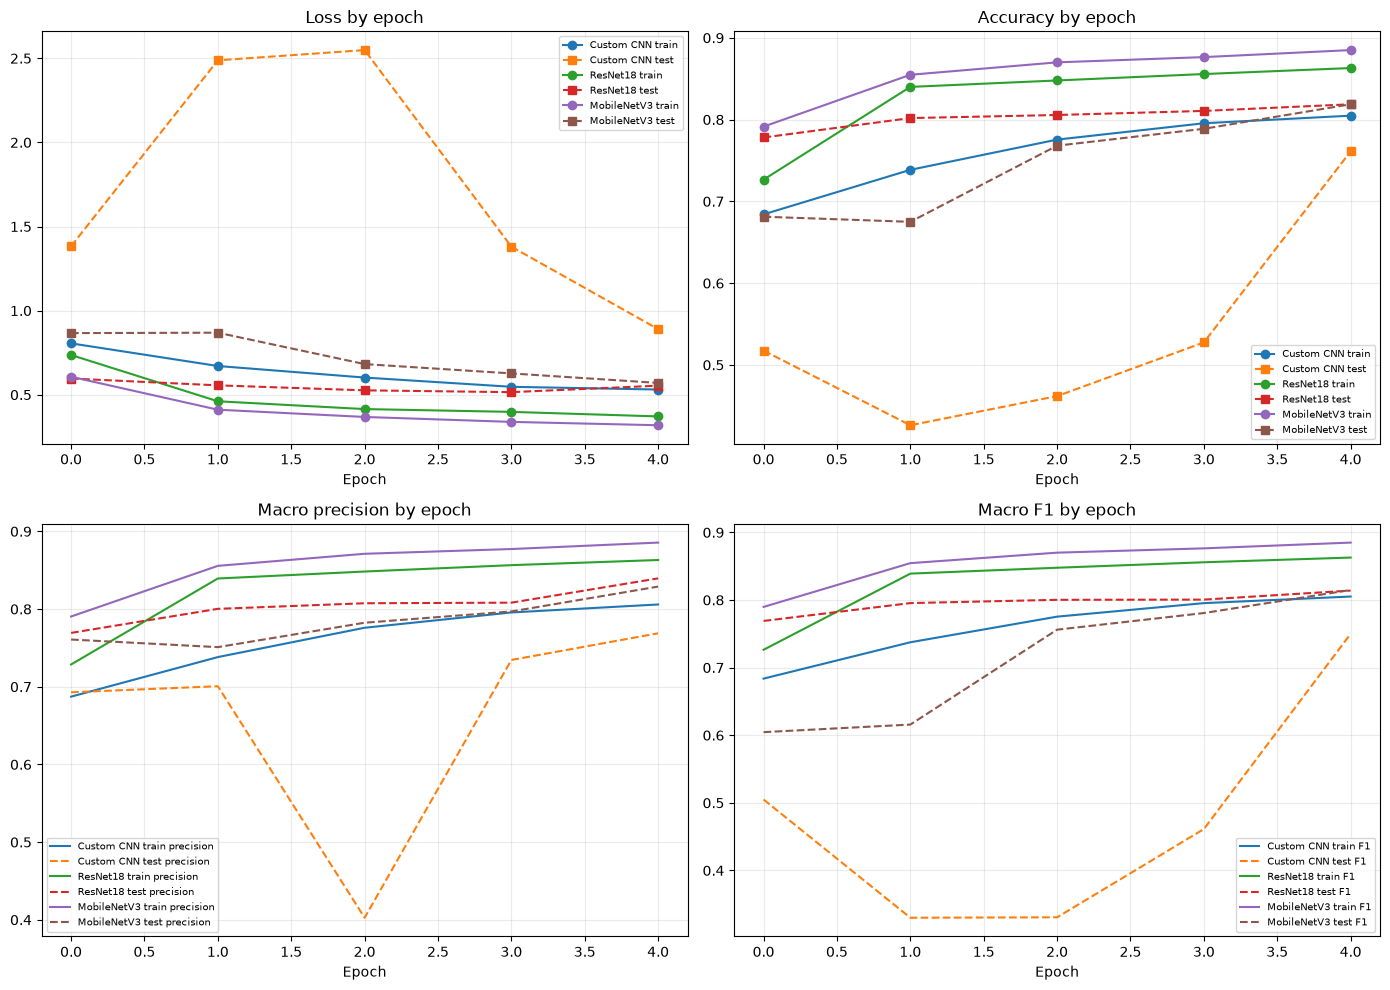

In [ ]:
def print_classification_report_from_matrix(matrix, names):
    print(f"{'Class':<14}{'Precision':>12}{'Recall':>12}{'F1-score':>12}{'Support':>12}")
    for index, name in enumerate(names):
        true_positive = matrix[index, index]
        predicted_positive = matrix[:, index].sum()
        actual_positive = matrix[index, :].sum()
        precision = true_positive / predicted_positive if predicted_positive else 0.0
        recall = true_positive / actual_positive if actual_positive else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        print(f"{name:<14}{precision:>12.3f}{recall:>12.3f}{f1:>12.3f}{actual_positive:>12d}")
    print(f"\nOverall accuracy: {np.trace(matrix) / matrix.sum():.3f}")


def plot_model_history(model_name, history):
    figure, axes = plt.subplots(2, 3, figsize=(18, 10))
    epochs = range(1, len(history["train_loss"]) + 1)
    plots = [
        (0, 0, "loss", "Loss"),
        (0, 1, "accuracy", "Accuracy"),
        (0, 2, "precision", "Macro precision"),
        (1, 0, "recall", "Macro recall"),
        (1, 1, "f1", "Macro F1"),
        (1, 2, "mean_confidence", "Mean confidence / uncertainty"),
    ]
    for row, column, metric, title in plots:
        axes[row, column].plot(epochs, history[f"train_{metric}"], label="Train", marker="o", markersize=3)
        axes[row, column].plot(epochs, history[f"test_{metric}"], label="Test", marker="s", markersize=3)
        if metric == "mean_confidence":
            axes[row, column].plot(epochs, [1 - value for value in history["test_mean_confidence"]], label="Test uncertainty", linestyle=":")
        axes[row, column].set_title(f"{model_name}: {title}")
        axes[row, column].set_xlabel("Epoch")
        axes[row, column].grid(alpha=0.25)
        axes[row, column].legend(fontsize=8)
    axes[0, 0].set_ylabel("Cross-entropy")
    axes[0, 1].set_ylim(0, 1.05)
    axes[0, 2].set_ylim(0, 1.05)
    axes[1, 0].set_ylim(0, 1.05)
    axes[1, 1].set_ylim(0, 1.05)
    axes[1, 2].set_ylim(0, 1.05)
    figure.tight_layout()
    graph_path = RUN_DIR / f"{model_name.lower().replace(' ', '_')}_{RUN_ID}_complete_history.png"
    figure.savefig(graph_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Complete graph saved to: {graph_path}")


for model_name, history in histories.items():
    model = models_to_train[model_name]
    metrics = evaluate_model(model, test_loader, nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING))
    print(f"\n{model_name} final test metrics:")
    print(
        f"loss={metrics['loss']:.4f} | accuracy={metrics['accuracy']:.4f} | "
        f"precision={metrics['precision']:.4f} | recall={metrics['recall']:.4f} | "
        f"f1={metrics['f1']:.4f} | confidence={metrics['mean_confidence']:.4f} | "
        f"uncertainty={metrics['uncertainty']:.4f}"
    )
    print_classification_report_from_matrix(metrics["matrix"], class_names)
    figure, axis = plt.subplots(figsize=(6, 5))
    image = axis.imshow(metrics["matrix"], cmap="Blues")
    axis.set_title(f"{model_name} final test confusion matrix")
    axis.set_xlabel("Predicted label")
    axis.set_ylabel("True label")
    axis.set_xticks(range(len(class_names)), class_names, rotation=35, ha="right")
    axis.set_yticks(range(len(class_names)), class_names)
    for row in range(len(class_names)):
        for column in range(len(class_names)):
            axis.text(column, row, metrics["matrix"][row, column], ha="center", va="center")
    figure.colorbar(image, ax=axis)
    figure.tight_layout()
    plt.show()
    plot_model_history(model_name, history)

if histories:
    figure, axes = plt.subplots(2, 4, figsize=(20, 9))
    comparison_metrics = ["loss", "accuracy", "precision", "recall", "f1", "mean_confidence", "uncertainty", "learning_rate"]
    for axis, metric in zip(axes.flat, comparison_metrics):
        for model_name, history in histories.items():
            values = history[f"test_{metric}"] if metric != "learning_rate" else history[metric]
            axis.plot(range(1, len(values) + 1), values, marker="o", markersize=2, label=model_name)
        axis.set_title(f"Test {metric.replace('_', ' ').title()}")
        axis.set_xlabel("Epoch")
        axis.grid(alpha=0.25)
        axis.legend(fontsize=7)
    figure.tight_layout()
    comparison_path = RUN_DIR / f"all_models_{RUN_ID}_comparison.png"
    figure.savefig(comparison_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"All-model comparison graph saved to: {comparison_path}")
else:
    print("No trained model histories found. Run the three algorithm cells first.")

In [ ]:
def predict_brain_mri(image_path, model_name="ResNet18"):
    """Predict one MRI image and return the predicted class and confidence."""
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")
    if model_name not in models_to_train:
        raise ValueError(f"Choose one of: {list(models_to_train)}")

    image = Image.open(image_path).convert("RGB")
    input_tensor = test_transforms(image).unsqueeze(0).to(device)
    model = models_to_train[model_name]
    model.eval()
    with torch.no_grad():
        probabilities = torch.softmax(model(input_tensor), dim=1)[0]
    confidence, class_index = probabilities.max(dim=0)
    predicted_class = class_names[class_index.item()]

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"{predicted_class} ({confidence.item() * 100:.2f}% confidence)")
    plt.show()
    return predicted_class, confidence.item()


# Example: replace this with any image path from Testing or another MRI folder.
# prediction = predict_brain_mri(TEST_DIR / class_names[0] / "example.jpg", "ResNet18")